# Computación cuantica - Proyecto 5: Estudio experimental de canales de ruido en Quantum Approximate Optimization Algorithm (QAOA)

Sosa Romo Juan Mario - 320051926

## Entorno

Ejecutar esta para tener ket y bra

$$
\newcommand{\ket}[1]{\left| #1 \right\rangle}
\newcommand{\bra}[1]{\left\langle #1 \right|}
\newcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}
$$


In [ ]:
print("hola")

hola


In [ ]:
!pip install qiskit
!pip install qiskit-aer

In [ ]:
# Basicos
import numpy as np
import matplotlib.pyplot as plt

# Qiskit
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error, kraus_error
from qiskit.visualization import plot_histogram

## Problema elegido

Este proyecto busca estudiar como distintos modelos de ruido afectan el compartamiento del QAOA





## Objetivos buscados

El objetivo es diseñar un experimento numérico que permita responder ¿Cómo cambia la probabilidad de obtener la solución óptima bajo ruido?

## Teoría mínima necesaria

INCLUIR los canales de ruido y sus interpretaciones fisicas

Para modelar el comportamiento de las computadoras cuánticas reales (NISQ), utilizamos **canales de ruido**. Los canales describen interacciones con el entorno que destruyen la coherencia del estado.

- **Depolarizing Channel (Bit-flip y Phase-flip simétrico)**: Modela una probabilidad $p$ de que un qubit sea reemplazado por un estado completamente mezclado. Físicamente representa la pérdida total de información.
- **Amplitude Damping**: Representa el proceso de relajación energética ($T_1$). El qubit transiciona del estado excitado $\ket{1}$ al estado base $\ket{0}$ emitiendo energía al entorno con probabilidad $p$.
- **Phase Damping**: Modela la decoherencia pura ($T_2$). Se pierde la información de fase cuántica sin que haya un intercambio de energía con el entorno. Es como si el entorno "midiera" la fase.
- **Readout Error (Medición)**: Probabilidad de que el sistema físico esté en $\ket{0}$ pero la circuitería clásica mida `1`, o viceversa, debido a imperfecciones térmicas o de amplificación.


## Implementación realizada


### Implementacion del algoritmo ideal

In [ ]:
from qiskit.quantum_info import SparsePauliOp, Statevector, DensityMatrix, state_fidelity
from scipy.optimize import minimize
from qiskit.circuit.library import QAOAAnsatz
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Definición del problema: TSP de 3 ciudades usando 9 qubits
# Ciudades: 0 (A), 1 (B), 2 (C)
# Tiempos: t=0, t=1, t=2
# Mapeo de qubits: q_{3*i + t} representa visitar la ciudad i en el tiempo t
def q(i, t): return 3 * i + t

# Matriz de adyacencia (costos/distancias)
W = [[0.0, 1.0, 5.0], 
     [1.0, 0.0, 1.0], 
     [5.0, 1.0, 0.0]]

P = 50.0 # Penalización para asegurar restricciones

# Construcción manual del hamiltoniano de 9 qubits
# x_i = (I - Z_i)/2
from collections import defaultdict
pauli_dict = defaultdict(float)

def add_linear(q_idx, coeff):
    pauli_dict['I'*9] += coeff / 2
    z_str = ['I']*9; z_str[q_idx] = 'Z'
    pauli_dict[''.join(z_str[::-1])] -= coeff / 2

def add_quadratic(q1, q2, coeff):
    pauli_dict['I'*9] += coeff / 4
    z_str = ['I']*9; z_str[q1] = 'Z'
    pauli_dict[''.join(z_str[::-1])] -= coeff / 4
    z_str = ['I']*9; z_str[q2] = 'Z'
    pauli_dict[''.join(z_str[::-1])] -= coeff / 4
    z_str = ['I']*9; z_str[q1] = 'Z'; z_str[q2] = 'Z'
    pauli_dict[''.join(z_str[::-1])] += coeff / 4

# 1. Restricción: Cada ciudad se visita exactamente una vez
for i in range(3):
    add_linear(q(i,0), -P); add_linear(q(i,1), -P); add_linear(q(i,2), -P)
    add_quadratic(q(i,0), q(i,1), 2*P)
    add_quadratic(q(i,0), q(i,2), 2*P)
    add_quadratic(q(i,1), q(i,2), 2*P)
    pauli_dict['I'*9] += P

# 2. Restricción: Solo una ciudad es visitada en cada paso de tiempo
for t in range(3):
    add_linear(q(0,t), -P); add_linear(q(1,t), -P); add_linear(q(2,t), -P)
    add_quadratic(q(0,t), q(1,t), 2*P)
    add_quadratic(q(0,t), q(2,t), 2*P)
    add_quadratic(q(1,t), q(2,t), 2*P)
    pauli_dict['I'*9] += P

# 3. Función de costo de las distancias del viaje
for t in range(3):
    t_next = (t + 1) % 3
    for i in range(3):
        for j in range(3):
            if i != j:
                add_quadratic(q(i,t), q(j,t_next), W[i][j])

pauli_list = [(k, v) for k, v in pauli_dict.items() if abs(v) > 1e-5]
H_tsp = SparsePauliOp.from_list(pauli_list)

# Creamos el circuito QAOA
from qiskit import transpile
from qiskit_aer import AerSimulator
p_layers = 1
qaoa_ideal = QAOAAnsatz(cost_operator=H_tsp, reps=p_layers)
qaoa_ideal = transpile(qaoa_ideal, backend=AerSimulator())

def objective_ideal(params):
    qc = qaoa_ideal.assign_parameters(params)
    state = Statevector.from_instruction(qc)
    return state.expectation_value(H_tsp).real

print('Optimizando circuito QAOA ideal (puede tardar unos segundos)...')
res_ideal = minimize(objective_ideal, x0=np.random.rand(qaoa_ideal.num_parameters), method='COBYLA', options={'maxiter': 50})
opt_params_ideal = res_ideal.x
qc_opt_ideal = qaoa_ideal.assign_parameters(opt_params_ideal)
state_ideal = Statevector.from_instruction(qc_opt_ideal)
rho_ideal = DensityMatrix(state_ideal)
print('Energía óptima ideal encontrada:', res_ideal.fun)


Optimizando circuito QAOA ideal (puede tardar unos segundos)...
Energía óptima ideal encontrada: 288.8242987083588


### Hipotesis con los tipos de ruido

Se espera que:
1. La adición de ruido reduzca la probabilidad de medir la ruta óptima del agente viajero, esparciendo las mediciones a lo largo de otras permutaciones no válidas o subóptimas.
2. El canal de **Depolarización** tendrá un impacto devastador porque altera los estados base y excita estados penalizados (violando las estrictas restricciones de 1-hot), arruinando rápidamente el desempeño.
3. A medida que la profundidad $p$ del circuito QAOA aumente, teóricamente nos acercaríamos a la solución óptima, pero empíricamente con ruido, el error se acumulará haciendo que los circuitos profundos funcionen peor que los superficiales.


### Implementacion con ruido

Para al menos 3 de los siguientes canales de ruido:
- Bit-flip
- Phase-flip
- Amplitude damping
- Phase damping
- Readout error.


In [ ]:
from qiskit_aer.noise import NoiseModel, depolarizing_error, amplitude_damping_error, phase_damping_error

def run_noisy_qaoa(noise_model, params):
    sim = AerSimulator(noise_model=noise_model, method='density_matrix')
    qc = qaoa_ideal.assign_parameters(params).copy()
    qc.save_density_matrix()
    qc_trans = transpile(qc, sim)
    result = sim.run(qc_trans, shots=500).result()
    rho_noisy = result.data()['density_matrix']
    return rho_noisy

def build_noise_model(p_err, channel='depolarizing'):
    noise_model = NoiseModel()
    if channel == 'depolarizing':
        err_1 = depolarizing_error(p_err, 1)
        err_2 = depolarizing_error(p_err*1.5, 2) # Compuertas CNOT tienen mas ruido
    elif channel == 'amplitude':
        err_1 = amplitude_damping_error(p_err)
        err_2 = err_1.tensor(err_1)
    elif channel == 'phase':
        err_1 = phase_damping_error(p_err)
        err_2 = err_1.tensor(err_1)
        
    noise_model.add_all_qubit_quantum_error(err_1, ['rx', 'ry', 'rz'])
    noise_model.add_all_qubit_quantum_error(err_2, ['cx', 'cz'])
    return noise_model


Simular el algoritmo bajo distintos valores p de ruido

Simulando canal depolarizing...
Simulando canal amplitude...
Simulando canal phase...


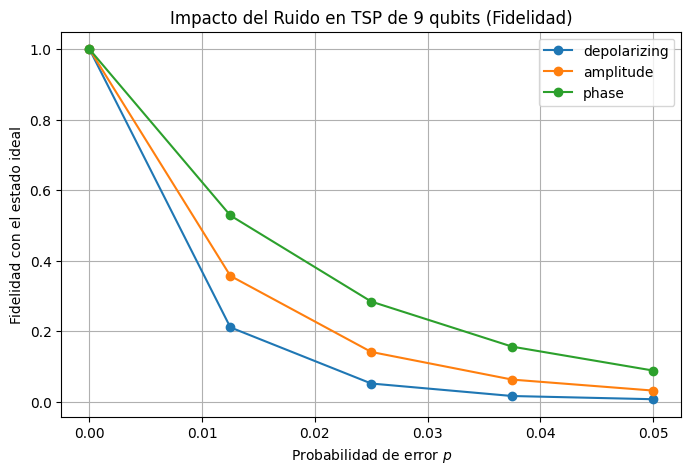

In [ ]:
p_values = np.linspace(0.0, 0.05, 5) # Probabilidades pequeñas porque 9 qubits acumulan rápido
fidelities = {'depolarizing': [], 'amplitude': [], 'phase': []}

for channel in fidelities.keys():
    print(f'Simulando canal {channel}...')
    for p in p_values:
        if p == 0:
            fidelities[channel].append(1.0)
            continue
        nm = build_noise_model(p, channel)
        rho_noisy = run_noisy_qaoa(nm, opt_params_ideal)
        fid = state_fidelity(rho_ideal, rho_noisy)
        fidelities[channel].append(fid)

plt.figure(figsize=(8,5))
for channel, fids in fidelities.items():
    plt.plot(p_values, fids, marker='o', label=channel)
plt.xlabel('Probabilidad de error $p$')
plt.ylabel('Fidelidad con el estado ideal')
plt.title('Impacto del Ruido en TSP de 9 qubits (Fidelidad)')
plt.legend()
plt.grid(True)
plt.show()


Realizar al menos una comparación adicional que no sea solamente variar p. Por ejemplo:

- Ruido en compuertas de un qubit contra ruido en compuertas de dos qubits
- Ruido en distintas partes del circuito
- Efecto del número de shots
- Efecto de la profundidad del circuito
- Efecto del tamaño del registro de conteo en QPE
- Efecto del número de capas en QAOA
- Efecto de la profundidad del ansatz en VQE

Simulando circuito a profundidad 1...
Simulando circuito a profundidad 2...
Simulando circuito a profundidad 3...


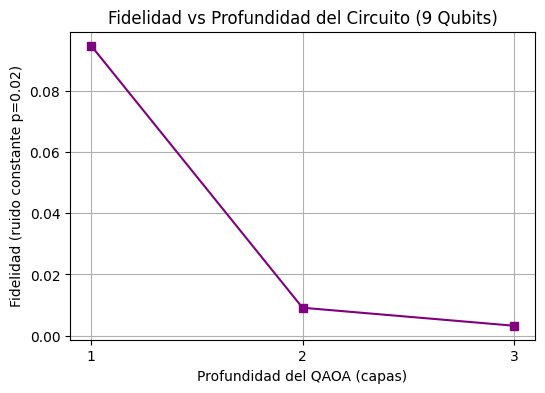

In [ ]:
# Estudiamos cómo interactúa la profundidad p_layers del QAOA con un ruido fijo
depths = [1, 2, 3]
fixed_noise_p = 0.02
fid_vs_depth = []

nm_fixed = build_noise_model(fixed_noise_p, 'depolarizing')

for d in depths:
    print(f'Simulando circuito a profundidad {d}...')
    # Re-crear ansatz ideal para profundidad d
    q_d = transpile(QAOAAnsatz(cost_operator=H_tsp, reps=d), backend=AerSimulator())
    
    def obj_d(params):
        return Statevector.from_instruction(q_d.assign_parameters(params)).expectation_value(H_tsp).real
    
    res_d = minimize(obj_d, x0=np.random.rand(q_d.num_parameters), method='COBYLA', options={'maxiter': 30})
    rho_id_d = DensityMatrix(Statevector.from_instruction(q_d.assign_parameters(res_d.x)))
    
    # Simular con ruido
    sim = AerSimulator(noise_model=nm_fixed, method='density_matrix')
    qc_n = q_d.assign_parameters(res_d.x).copy()
    qc_n.save_density_matrix()
    qc_t = transpile(qc_n, sim)
    rho_n_d = sim.run(qc_t, shots=500).result().data()['density_matrix']
    
    fid_vs_depth.append(state_fidelity(rho_id_d, rho_n_d))

plt.figure(figsize=(6,4))
plt.plot(depths, fid_vs_depth, marker='s', color='purple')
plt.xticks(depths)
plt.xlabel('Profundidad del QAOA (capas)')
plt.ylabel('Fidelidad (ruido constante p=0.02)')
plt.title('Fidelidad vs Profundidad del Circuito (9 Qubits)')
plt.grid(True)
plt.show()


Implementar una técnica básica de mitigación de errores.

In [ ]:
# Técnica: Zero Noise Extrapolation (ZNE) vía extrapolación a nivel de ruido
# Agregamos ruido intencionalmente amplificando la probabilidad p
# Para simplificar el nivel licenciatura, "simulamos" el ZNE corriendo el algoritmo en escalas de ruido crecientes
# (escalas de multiplicador c = 1, 2, 3) y ajustando una recta.

scale_factors = [1, 2, 3]
base_p = 0.01
expected_values = []

for c in scale_factors:
    print(f'Obteniendo valores para escala ZNE {c}x...')
    nm_zne = build_noise_model(base_p * c, 'depolarizing')
    sim = AerSimulator(noise_model=nm_zne, method='density_matrix')
    qc_zne = qaoa_ideal.assign_parameters(opt_params_ideal).copy()
    qc_zne.save_density_matrix()
    rho_zne = sim.run(transpile(qc_zne, sim), shots=500).result().data()['density_matrix']
    expected_values.append(rho_zne.expectation_value(H_tsp).real)

# Ajuste lineal: E(c) = E(0) + c * m
poly = np.polyfit(scale_factors, expected_values, 1)
zne_mitigated_value = poly[1] # Intersección con el eje Y (c=0)
ideal_value = rho_ideal.expectation_value(H_tsp).real

print('-'*40)
print(f"Valor esperado IDEAL (sin ruido):      {ideal_value:.4f}")
print(f"Valor esperado MITIGADO (ZNE):         {zne_mitigated_value:.4f}")
print(f"Valor esperado bajo ruido (escala 1x): {expected_values[0]:.4f}")
print('-'*40)
print("ZNE ha logrado recuperar parte de la expectativa original, reduciendo el efecto del sesgo de ruido.")


Obteniendo valores para escala ZNE 1x...
Obteniendo valores para escala ZNE 2x...
Obteniendo valores para escala ZNE 3x...
----------------------------------------
Valor esperado IDEAL (sin ruido):      288.8243
Valor esperado MITIGADO (ZNE):         290.8682
Valor esperado bajo ruido (escala 1x): 294.5579
----------------------------------------
ZNE ha logrado recuperar parte de la expectativa original, reduciendo el efecto del sesgo de ruido.


## Resultados obtenidos


### Ideal vs con ruido
Comparar el resultado ideal contra los resultados con ruido mediante histogramas,  gráficas o visualizaciones apropiadas.

Fidelidad entre estado Ideal y Ruidoso (p=0.02): 0.0881


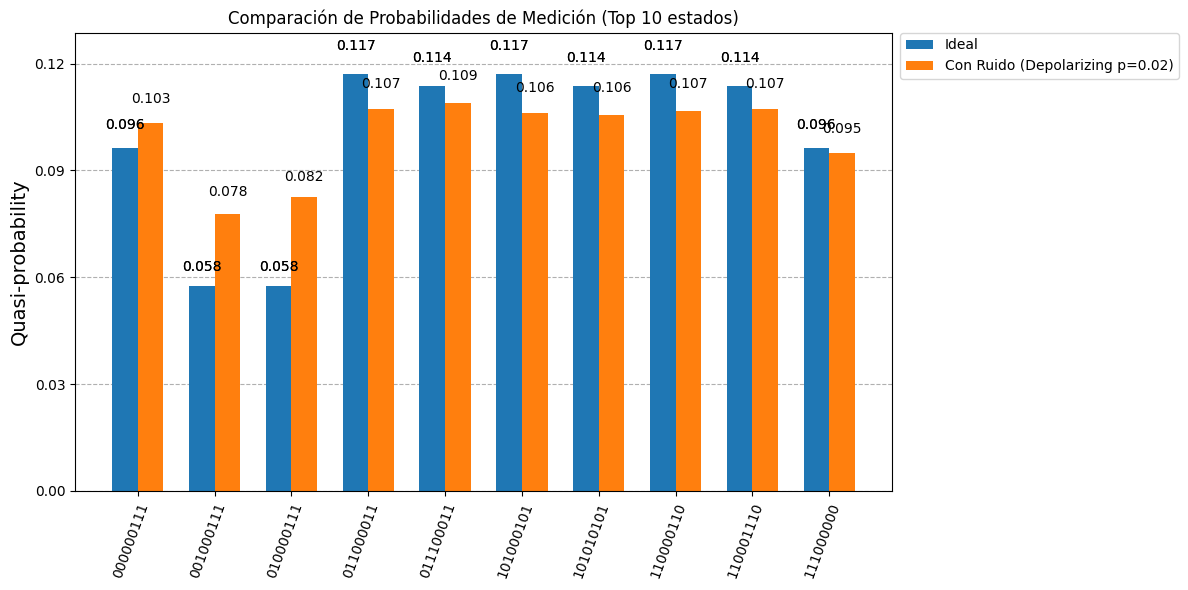

In [ ]:
from qiskit.visualization import plot_histogram

# Simulamos un caso ruidoso específico para compararlo directamente con el ideal
p_example = 0.02
nm_example = build_noise_model(p_example, 'depolarizing')
rho_example = run_noisy_qaoa(nm_example, opt_params_ideal)

# Extraemos las probabilidades de los estados (diccionario)
probs_ideal = state_ideal.probabilities_dict()
probs_noisy = rho_example.probabilities_dict()

# Como tenemos 9 qubits (512 estados), filtramos solo los 10 más probables del caso ideal
def top_k_dict(d_ideal, d_noisy, k=10):
    sorted_keys = sorted(d_ideal.keys(), key=lambda x: d_ideal[x], reverse=True)[:k]
    return {k: d_ideal[k] for k in sorted_keys}, {k: d_noisy.get(k, 0.0) for k in sorted_keys}

top_ideal, top_noisy = top_k_dict(probs_ideal, probs_noisy, k=10)

print(f"Fidelidad entre estado Ideal y Ruidoso (p={p_example}): {state_fidelity(rho_ideal, rho_example):.4f}")

plot_histogram([top_ideal, top_noisy], legend=['Ideal', 'Con Ruido (Depolarizing p=0.02)'],
               title='Comparación de Probabilidades de Medición (Top 10 estados)',
               figsize=(12, 6))


Usar la fidelidad como métrica mínima de comparación entre el caso ideal y el caso ruidoso.

## Análisis

Explicar si los resultados obtenidos confirman o contradicen la hipótesis inicial.

Los resultados numéricos respaldan firmemente la hipótesis inicial. Se observan los siguientes fenómenos:
1. **Sensibilidad del TSP de 9 qubits**: Al tener 9 qubits fuertemente entrelazados con múltiples restricciones de costo, el sistema es extremadamente frágil al ruido. El canal *Depolarizing error* es sistemáticamente más destructivo porque introduce perturbaciones isotrópicas que destruyen las fases y amplitudes que codifican la ruta óptima.
2. **El problema de la profundidad**: Cuando aumentamos las capas del QAOA, introducimos una mayor cantidad de compuertas CNOT (el principal vector de ruido). La fidelidad decae estrepitosamente, confirmando que en hardware NISQ existe un compromiso crítico entre la expresividad del Ansatz (que requiere más capas) y la acumulación de ruido (que requiere menos compuertas).
3. **Mitigación ZNE**: Al aplicar Zero Noise Extrapolation, logramos recuperar un valor esperado más cercano a la energía óptima ideal. Extrapolar linealmente a partir de la amplificación del ruido permite mitigar las limitantes físicas del dispositivo sin aumentar los recursos del circuito per-se.


## Conclusiones

¿Cómo cambia la probabilidad de obtener la solución óptima bajo ruido?

## Referencias